In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [8]:
df=pd.read_csv(
    '../data/raw/time_series_60min_singleindex.csv',
    index_col=0,
    parse_dates=True,
    low_memory=False
)

print("Shape:", df.shape)
print("\nDate range:", df.index.min(), "to" , df.index.max())
print("\nTotal:", len(df.columns))
print("\nFirst few columns:", df.columns[:10].tolist())

Shape: (50401, 299)

Date range: 2014-12-31 23:00:00+00:00 to 2020-09-30 23:00:00+00:00

Total: 299

First few columns: ['cet_cest_timestamp', 'AT_load_actual_entsoe_transparency', 'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead', 'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_generation_actual']


In [9]:
germany_cols=[col for col in df.columns if col.startswith('DE')]
print(f"Total germany columns: {len(germany_cols)}")
print("\n".join(germany_cols))

Total germany columns: 41
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation_actual
DE_amprion_load_actual_entsoe_transparency
DE_amprion_load_forecast_entsoe_transparency
DE_amprion_solar_generation_actual
DE_amprion_wi

In [11]:
cols_needed=[
    'DE_load_actual_entsoe_transparency',
    'DE_load_forecast_entsoe_transparency',
    'DE_solar_generation_actual',
    'DE_wind_generation_actual',
    'DE_wind_onshore_generation_actual',
    'DE_wind_offshore_generation_actual',
    'DE_LU_price_day_ahead'
]

df_de=df[cols_needed].copy()
print("Shape:", df_de.shape)
print("\nMissing values:",df_de.isnull().sum())
print("\nFirst 5 rows:",df_de.head())

Shape: (50401, 7)

Missing values: DE_load_actual_entsoe_transparency          1
DE_load_forecast_entsoe_transparency       25
DE_solar_generation_actual                104
DE_wind_generation_actual                  75
DE_wind_onshore_generation_actual          73
DE_wind_offshore_generation_actual         75
DE_LU_price_day_ahead                   32861
dtype: int64

First 5 rows:                            DE_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2014-12-31 23:00:00+00:00                                 NaN   
2015-01-01 00:00:00+00:00                             41151.0   
2015-01-01 01:00:00+00:00                             40135.0   
2015-01-01 02:00:00+00:00                             39106.0   
2015-01-01 03:00:00+00:00                             38765.0   

                           DE_load_forecast_entsoe_transparency  \
utc_timestamp                                                     
2014-12-31 23:00:00+00:00

In [13]:
price_available=df_de['DE_LU_price_day_ahead'].dropna()
print("Price data available from:",price_available.index.min())
print("Price data available to:",price_available.index.max())
print("Total rows with price:",len(price_available))

de_price_cols=[col for col in df.columns if 'price' in col.lower()]
print("\nAll price columns in dataset:")
print("\n".join(de_price_cols))

Price data available from: 2018-09-30 23:00:00+00:00
Price data available to: 2020-09-30 22:00:00+00:00
Total rows with price: 17540

All price columns in dataset:
AT_price_day_ahead
DE_LU_price_day_ahead
DK_1_price_day_ahead
DK_2_price_day_ahead
GB_GBN_price_day_ahead
IE_sem_price_day_ahead
IT_BRNN_price_day_ahead
IT_CNOR_price_day_ahead
IT_CSUD_price_day_ahead
IT_FOGN_price_day_ahead
IT_GR_price_day_ahead
IT_NORD_price_day_ahead
IT_NORD_AT_price_day_ahead
IT_NORD_CH_price_day_ahead
IT_NORD_FR_price_day_ahead
IT_NORD_SI_price_day_ahead
IT_PRGP_price_day_ahead
IT_ROSN_price_day_ahead
IT_SACO_AC_price_day_ahead
IT_SACO_DC_price_day_ahead
IT_SARD_price_day_ahead
IT_SICI_price_day_ahead
IT_SUD_price_day_ahead
NO_1_price_day_ahead
NO_2_price_day_ahead
NO_3_price_day_ahead
NO_4_price_day_ahead
NO_5_price_day_ahead
SE_1_price_day_ahead
SE_2_price_day_ahead
SE_3_price_day_ahead
SE_4_price_day_ahead


In [14]:
df_de=df_de.dropna(subset=['DE_LU_price_day_ahead'])
df_de.columns=[
    'load_actual',
    'load_forecast',
    'solar_gen',
    'wind_gen',
    'wind_onshore',
    'wind_offshore',
    'price_day_ahead'
]

print("Shape after filter:", df_de.shape)
print("Date range:",df_de.index.min(), "to" , df_de.index.max())
print("\nMissing values:")
print(df_de.isnull().sum())
print("\nBasic stats:")
print(df_de.describe().round(2))

Shape after filter: (17540, 7)
Date range: 2018-09-30 23:00:00+00:00 to 2020-09-30 22:00:00+00:00

Missing values:
load_actual        0
load_forecast      0
solar_gen          0
wind_gen           0
wind_onshore       0
wind_offshore      0
price_day_ahead    0
dtype: int64

Basic stats:
       load_actual  load_forecast  solar_gen  wind_gen  wind_onshore  \
count     17540.00       17540.00   17540.00  17540.00      17540.00   
mean      55152.22       54500.01    5006.69  14371.75      11569.61   
std        9986.17        9417.05    7653.50  10315.25       9065.79   
min       31923.00       32425.00       0.00    136.00        119.00   
25%       47013.00       46841.50       0.00   6173.75       4536.75   
50%       54730.00       54380.00     156.00  11728.00       8893.00   
75%       63445.00       62214.75    8003.25  20340.25      16336.25   
max       76925.00       73744.00   32947.00  46064.00      40752.00   

       wind_offshore  price_day_ahead  
count       17540.00  

In [15]:
# ── Option 2: Two separate dataframes ──────────────────────

# All Germany columns we need
cols_needed = [
    'DE_load_actual_entsoe_transparency',
    'DE_load_forecast_entsoe_transparency',
    'DE_solar_generation_actual',
    'DE_wind_generation_actual',
    'DE_wind_onshore_generation_actual',
    'DE_wind_offshore_generation_actual',
    'DE_LU_price_day_ahead'
]

df_all = df[cols_needed].copy()

df_all.columns = [
    'load_actual',
    'load_forecast',
    'solar_gen',
    'wind_gen',
    'wind_onshore',
    'wind_offshore',
    'price_day_ahead'
]

# ── Dataset 1: LOAD (2015-2020, full 5 years) ──────────────
df_load = df_all[['load_actual', 'load_forecast',
                   'solar_gen', 'wind_gen',
                   'wind_onshore', 'wind_offshore']].copy()

# Drop rows where load is missing
df_load = df_load.dropna(subset=['load_actual'])

print("=== LOAD DATASET ===")
print("Shape:", df_load.shape)
print("Date range:", df_load.index.min(), "to", df_load.index.max())
print("Missing values:\n", df_load.isnull().sum())

# ── Dataset 2: PRICE (2018-2020, where price exists) ───────
df_price = df_all.dropna(subset=['price_day_ahead']).copy()

print("\n=== PRICE DATASET ===")
print("Shape:", df_price.shape)
print("Date range:", df_price.index.min(), "to", df_price.index.max())
print("Missing values:\n", df_price.isnull().sum())

=== LOAD DATASET ===
Shape: (50400, 6)
Date range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Missing values:
 load_actual        0
load_forecast     24
solar_gen        103
wind_gen          74
wind_onshore      72
wind_offshore     74
dtype: int64

=== PRICE DATASET ===
Shape: (17540, 7)
Date range: 2018-09-30 23:00:00+00:00 to 2020-09-30 22:00:00+00:00
Missing values:
 load_actual        0
load_forecast      0
solar_gen          0
wind_gen           0
wind_onshore       0
wind_offshore      0
price_day_ahead    0
dtype: int64


In [25]:
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
from retry_requests import retry

# Setup client
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

def fetch_weather(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 52.52,        # Berlin
        "longitude": 13.41,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "windspeed_10m",
            "cloudcover",
            "shortwave_radiation"
        ],
        "timezone": "UTC"
    }
    
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()
    
    weather = pd.DataFrame({
        "temperature": hourly.Variables(0).ValuesAsNumpy(),
        "humidity":    hourly.Variables(1).ValuesAsNumpy(),
        "windspeed":   hourly.Variables(2).ValuesAsNumpy(),
        "cloudcover":  hourly.Variables(3).ValuesAsNumpy(),
        "solar_rad":   hourly.Variables(4).ValuesAsNumpy(),
    }, index=pd.date_range(
        start=pd.Timestamp(hourly.Time(), unit="s", tz="UTC"),
        end=pd.Timestamp(hourly.TimeEnd(), unit="s", tz="UTC"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ))
    
    return weather

# Fetch for both periods
print("Fetching weather for load dataset (2015-2020)...")
weather_load = fetch_weather("2015-01-01", "2020-09-30")
print("Done. Shape:", weather_load.shape)

print("\nFetching weather for price dataset (2018-10-01)...")
weather_price = fetch_weather("2018-10-01", "2020-09-30")
print("Done. Shape:", weather_price.shape)

print("\nWeather Load sample:")
print(weather_load.head())

Fetching weather for load dataset (2015-2020)...
Done. Shape: (50400, 5)

Fetching weather for price dataset (2018-10-01)...
Done. Shape: (17544, 5)

Weather Load sample:
                           temperature   humidity  windspeed  cloudcover  \
2015-01-01 00:00:00+00:00        3.789  95.859322  14.440443        71.0   
2015-01-01 01:00:00+00:00        3.639  95.178436  14.917212        69.0   
2015-01-01 02:00:00+00:00        3.339  94.493675  14.561099        95.0   
2015-01-01 03:00:00+00:00        2.989  93.807564  14.081478        82.0   
2015-01-01 04:00:00+00:00        2.339  93.775703  12.964998        67.0   

                           solar_rad  
2015-01-01 00:00:00+00:00        0.0  
2015-01-01 01:00:00+00:00        0.0  
2015-01-01 02:00:00+00:00        0.0  
2015-01-01 03:00:00+00:00        0.0  
2015-01-01 04:00:00+00:00        0.0  


In [26]:
# ── Merge weather into both datasets ──────────────────────

# Load dataset merge
df_load = df_load.merge(
    weather_load,
    left_index=True,
    right_index=True,
    how='left'
)

# Price dataset merge
df_price = df_price.merge(
    weather_price,
    left_index=True,
    right_index=True,
    how='left'
)

print("=== LOAD DATASET AFTER MERGE ===")
print("Shape:", df_load.shape)
print("Columns:", df_load.columns.tolist())
print("Missing values:\n", df_load.isnull().sum())

print("\n=== PRICE DATASET AFTER MERGE ===")
print("Shape:", df_price.shape)
print("Columns:", df_price.columns.tolist())
print("Missing values:\n", df_price.isnull().sum())

=== LOAD DATASET AFTER MERGE ===
Shape: (50400, 11)
Columns: ['load_actual', 'load_forecast', 'solar_gen', 'wind_gen', 'wind_onshore', 'wind_offshore', 'temperature', 'humidity', 'windspeed', 'cloudcover', 'solar_rad']
Missing values:
 load_actual        0
load_forecast     24
solar_gen        103
wind_gen          74
wind_onshore      72
wind_offshore     74
temperature        0
humidity           0
windspeed          0
cloudcover         0
solar_rad          0
dtype: int64

=== PRICE DATASET AFTER MERGE ===
Shape: (17540, 12)
Columns: ['load_actual', 'load_forecast', 'solar_gen', 'wind_gen', 'wind_onshore', 'wind_offshore', 'price_day_ahead', 'temperature', 'humidity', 'windspeed', 'cloudcover', 'solar_rad']
Missing values:
 load_actual        0
load_forecast      0
solar_gen          0
wind_gen           0
wind_onshore       0
wind_offshore      0
price_day_ahead    0
temperature        1
humidity           1
windspeed          1
cloudcover         1
solar_rad          1
dtype: int6

In [28]:
# ── DATA CLEANING ──────────────────────────────────────────

# ── Price dataset: just 1 missing row, drop it ─────────────
df_price = df_price.dropna()

print("=== PRICE DATASET AFTER CLEANING ===")
print("Shape:", df_price.shape)
print("Missing values:\n", df_price.isnull().sum())

# ── Load dataset: forward fill small gaps ──────────────────
# These are short gaps (1-3 hours), forward fill is appropriate
df_load['load_forecast'] = df_load['load_forecast'].ffill()
df_load['solar_gen'] = df_load['solar_gen'].ffill()
df_load['wind_gen'] = df_load['wind_gen'].ffill()
df_load['wind_onshore'] = df_load['wind_onshore'].ffill()
df_load['wind_offshore'] = df_load['wind_offshore'].ffill()

print("\n=== LOAD DATASET AFTER CLEANING ===")
print("Shape:", df_load.shape)
print("Missing values:\n", df_load.isnull().sum())

# ── Outlier check ──────────────────────────────────────────
print("\n=== OUTLIER CHECK ===")
print("\nLoad actual:")
print(f"  Min: {df_load['load_actual'].min()}")
print(f"  Max: {df_load['load_actual'].max()}")
print(f"  Mean: {df_load['load_actual'].mean():.0f}")

print("\nPrice day ahead:")
print(f"  Min: {df_price['price_day_ahead'].min()}")
print(f"  Max: {df_price['price_day_ahead'].max()}")
print(f"  Mean: {df_price['price_day_ahead'].mean():.2f}")

# ── Check for negative prices (they actually happen in 
#    real electricity markets but let's flag them) ──────────
neg_prices = df_price[df_price['price_day_ahead'] < 0]
print(f"\nNegative price occurrences: {len(neg_prices)}")
if len(neg_prices) > 0:
    print("Sample negative prices:")
    print(neg_prices['price_day_ahead'].describe())

=== PRICE DATASET AFTER CLEANING ===
Shape: (17539, 12)
Missing values:
 load_actual        0
load_forecast      0
solar_gen          0
wind_gen           0
wind_onshore       0
wind_offshore      0
price_day_ahead    0
temperature        0
humidity           0
windspeed          0
cloudcover         0
solar_rad          0
dtype: int64

=== LOAD DATASET AFTER CLEANING ===
Shape: (50400, 11)
Missing values:
 load_actual      0
load_forecast    0
solar_gen        7
wind_gen         0
wind_onshore     0
wind_offshore    0
temperature      0
humidity         0
windspeed        0
cloudcover       0
solar_rad        0
dtype: int64

=== OUTLIER CHECK ===

Load actual:
  Min: 31307.0
  Max: 77549.0
  Mean: 55492

Price day ahead:
  Min: -90.01
  Max: 200.04
  Mean: 35.81

Negative price occurrences: 484
Sample negative prices:
count    484.000000
mean     -16.156198
std       21.131758
min      -90.010000
25%      -20.265000
50%       -6.605000
75%       -2.390000
max       -0.010000
Name: pri

In [29]:
print("PRICE: Zero missing values ✅")
print("LOAD: solar_gen has 7 remaining missing - let's check why")
print()

# Check those 7 remaining solar gaps
solar_nulls = df_load[df_load['solar_gen'].isnull()]
print("Solar null timestamps:")
print(solar_nulls.index.tolist())

# Fix them with interpolation
df_load['solar_gen'] = df_load['solar_gen'].interpolate(method='linear')

print("\nAfter interpolation:")
print("solar_gen missing:", df_load['solar_gen'].isnull().sum())

# Negative prices summary
print("\n=== NEGATIVE PRICES ===")
neg_prices = df_price[df_price['price_day_ahead'] < 0]
print(f"Count: {len(neg_prices)}")
print(f"Min price: {df_price['price_day_ahead'].min()}")
print(f"Max price: {df_price['price_day_ahead'].max()}")
print(f"Mean price: {df_price['price_day_ahead'].mean():.2f}")
print(f"% of time price is negative: {(len(neg_prices)/len(df_price)*100):.2f}%")

print("\n✅ Both datasets fully clean and ready for feature engineering")

PRICE: Zero missing values ✅
LOAD: solar_gen has 7 remaining missing - let's check why

Solar null timestamps:
[Timestamp('2015-01-01 00:00:00+0000', tz='UTC'), Timestamp('2015-01-01 01:00:00+0000', tz='UTC'), Timestamp('2015-01-01 02:00:00+0000', tz='UTC'), Timestamp('2015-01-01 03:00:00+0000', tz='UTC'), Timestamp('2015-01-01 04:00:00+0000', tz='UTC'), Timestamp('2015-01-01 05:00:00+0000', tz='UTC'), Timestamp('2015-01-01 06:00:00+0000', tz='UTC')]

After interpolation:
solar_gen missing: 7

=== NEGATIVE PRICES ===
Count: 484
Min price: -90.01
Max price: 200.04
Mean price: 35.81
% of time price is negative: 2.76%

✅ Both datasets fully clean and ready for feature engineering


In [30]:
# First 7 rows are midnight-6am Jan 1 2015
# Solar generation at night = 0, safe to fill
df_load['solar_gen'] = df_load['solar_gen'].fillna(0)

print("solar_gen missing after fix:", df_load['solar_gen'].isnull().sum())
print("✅ Load dataset 100% clean")

# ── Save clean datasets before feature engineering ─────────
df_load.to_csv('../data/processed/df_load_clean.csv')
df_price.to_csv('../data/processed/df_price_clean.csv')

print("\n✅ Saved to data/processed/")
print("  - df_load_clean.csv  →", df_load.shape)
print("  - df_price_clean.csv →", df_price.shape)

solar_gen missing after fix: 0
✅ Load dataset 100% clean

✅ Saved to data/processed/
  - df_load_clean.csv  → (50400, 11)
  - df_price_clean.csv → (17539, 12)


In [31]:
import numpy as np
import holidays

def add_features(df, country='DE'):
    df = df.copy()
    
    # ── Time features ──────────────────────────────────────
    df['hour']        = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['year']        = df.index.year
    df['day_of_year'] = df.index.dayofyear
    df['week_of_year']= df.index.isocalendar().week.astype(int)
    
    # ── Cyclical encoding ──────────────────────────────────
    # Tells model hour 23 and hour 0 are close, not far apart
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # ── Calendar features ──────────────────────────────────
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    de_holidays = holidays.Germany(
        years=df.index.year.unique().tolist()
    )
    df['is_holiday'] = df.index.normalize().isin(
        de_holidays.keys()
    ).astype(int)
    
    df['is_weekend_or_holiday'] = (
        (df['is_weekend'] == 1) | (df['is_holiday'] == 1)
    ).astype(int)
    
    # Peak hours: 8-10am and 6-8pm
    df['is_peak_hour'] = df['hour'].isin(
        [8, 9, 10, 18, 19, 20]
    ).astype(int)
    
    # ── Season ─────────────────────────────────────────────
    df['season'] = df['month'].map({
        12: 0, 1: 0, 2: 0,   # Winter
        3: 1,  4: 1, 5: 1,   # Spring
        6: 2,  7: 2, 8: 2,   # Summer
        9: 3, 10: 3, 11: 3   # Autumn
    })
    
    return df

# Apply to both datasets
df_load  = add_features(df_load)
df_price = add_features(df_price)

print("=== AFTER FEATURE ENGINEERING ===")
print("Load shape:", df_load.shape)
print("Price shape:", df_price.shape)
print("\nNew columns added:", [
    c for c in df_load.columns 
    if c not in ['load_actual','load_forecast','solar_gen',
                 'wind_gen','wind_onshore','wind_offshore',
                 'temperature','humidity','windspeed',
                 'cloudcover','solar_rad']
])

=== AFTER FEATURE ENGINEERING ===
Load shape: (50400, 29)
Price shape: (17539, 30)

New columns added: ['hour', 'day_of_week', 'month', 'quarter', 'year', 'day_of_year', 'week_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'is_weekend_or_holiday', 'is_peak_hour', 'season']


In [32]:
def add_lag_features(df, target_col):
    df = df.copy()
    
    # ── Lag features ───────────────────────────────────────
    # Same hour yesterday
    df[f'{target_col}_lag_24h']  = df[target_col].shift(24)
    # Same hour last week
    df[f'{target_col}_lag_168h'] = df[target_col].shift(168)
    # Previous hour
    df[f'{target_col}_lag_1h']   = df[target_col].shift(1)
    # 2 hours ago
    df[f'{target_col}_lag_2h']   = df[target_col].shift(2)
    # Same hour 2 days ago
    df[f'{target_col}_lag_48h']  = df[target_col].shift(48)
    
    # ── Rolling statistics ─────────────────────────────────
    # 24 hour rolling mean and std
    df[f'{target_col}_roll_mean_24h'] = (
        df[target_col].shift(1).rolling(24).mean()
    )
    df[f'{target_col}_roll_std_24h'] = (
        df[target_col].shift(1).rolling(24).std()
    )
    # 7 day rolling mean
    df[f'{target_col}_roll_mean_7d'] = (
        df[target_col].shift(1).rolling(168).mean()
    )
    # 7 day rolling std
    df[f'{target_col}_roll_std_7d'] = (
        df[target_col].shift(1).rolling(168).std()
    )
    # 24h rolling max and min
    df[f'{target_col}_roll_max_24h'] = (
        df[target_col].shift(1).rolling(24).max()
    )
    df[f'{target_col}_roll_min_24h'] = (
        df[target_col].shift(1).rolling(24).min()
    )
    
    return df

# ── Temperature lag features (weather affects load 
#    with a delay) ────────────────────────────────────────
def add_weather_lags(df):
    df = df.copy()
    df['temp_lag_1h']          = df['temperature'].shift(1)
    df['temp_lag_24h']         = df['temperature'].shift(24)
    df['temp_roll_mean_24h']   = df['temperature'].shift(1).rolling(24).mean()
    df['temp_roll_max_24h']    = df['temperature'].shift(1).rolling(24).max()
    df['humidity_lag_1h']      = df['humidity'].shift(1)
    return df

# Apply to load dataset
df_load = add_lag_features(df_load, 'load_actual')
df_load = add_weather_lags(df_load)

# Apply to price dataset  
df_price = add_lag_features(df_price, 'price_day_ahead')
df_price = add_lag_features(df_price, 'load_actual')
df_price = add_weather_lags(df_price)

# Drop rows with NaN created by lag features
# 168 hours = 1 week is the max lag, so first 168 rows 
# will have NaN
df_load_feat  = df_load.dropna()
df_price_feat = df_price.dropna()

print("=== FINAL FEATURE DATASETS ===")
print("Load shape:", df_load_feat.shape)
print("Price shape:", df_price_feat.shape)
print("\nLoad columns:", len(df_load_feat.columns))
print("Price columns:", len(df_price_feat.columns))
print("\nAny missing values?")
print("Load:", df_load_feat.isnull().sum().sum())
print("Price:", df_price_feat.isnull().sum().sum())

=== FINAL FEATURE DATASETS ===
Load shape: (50232, 45)
Price shape: (17371, 57)

Load columns: 45
Price columns: 57

Any missing values?
Load: 0
Price: 0


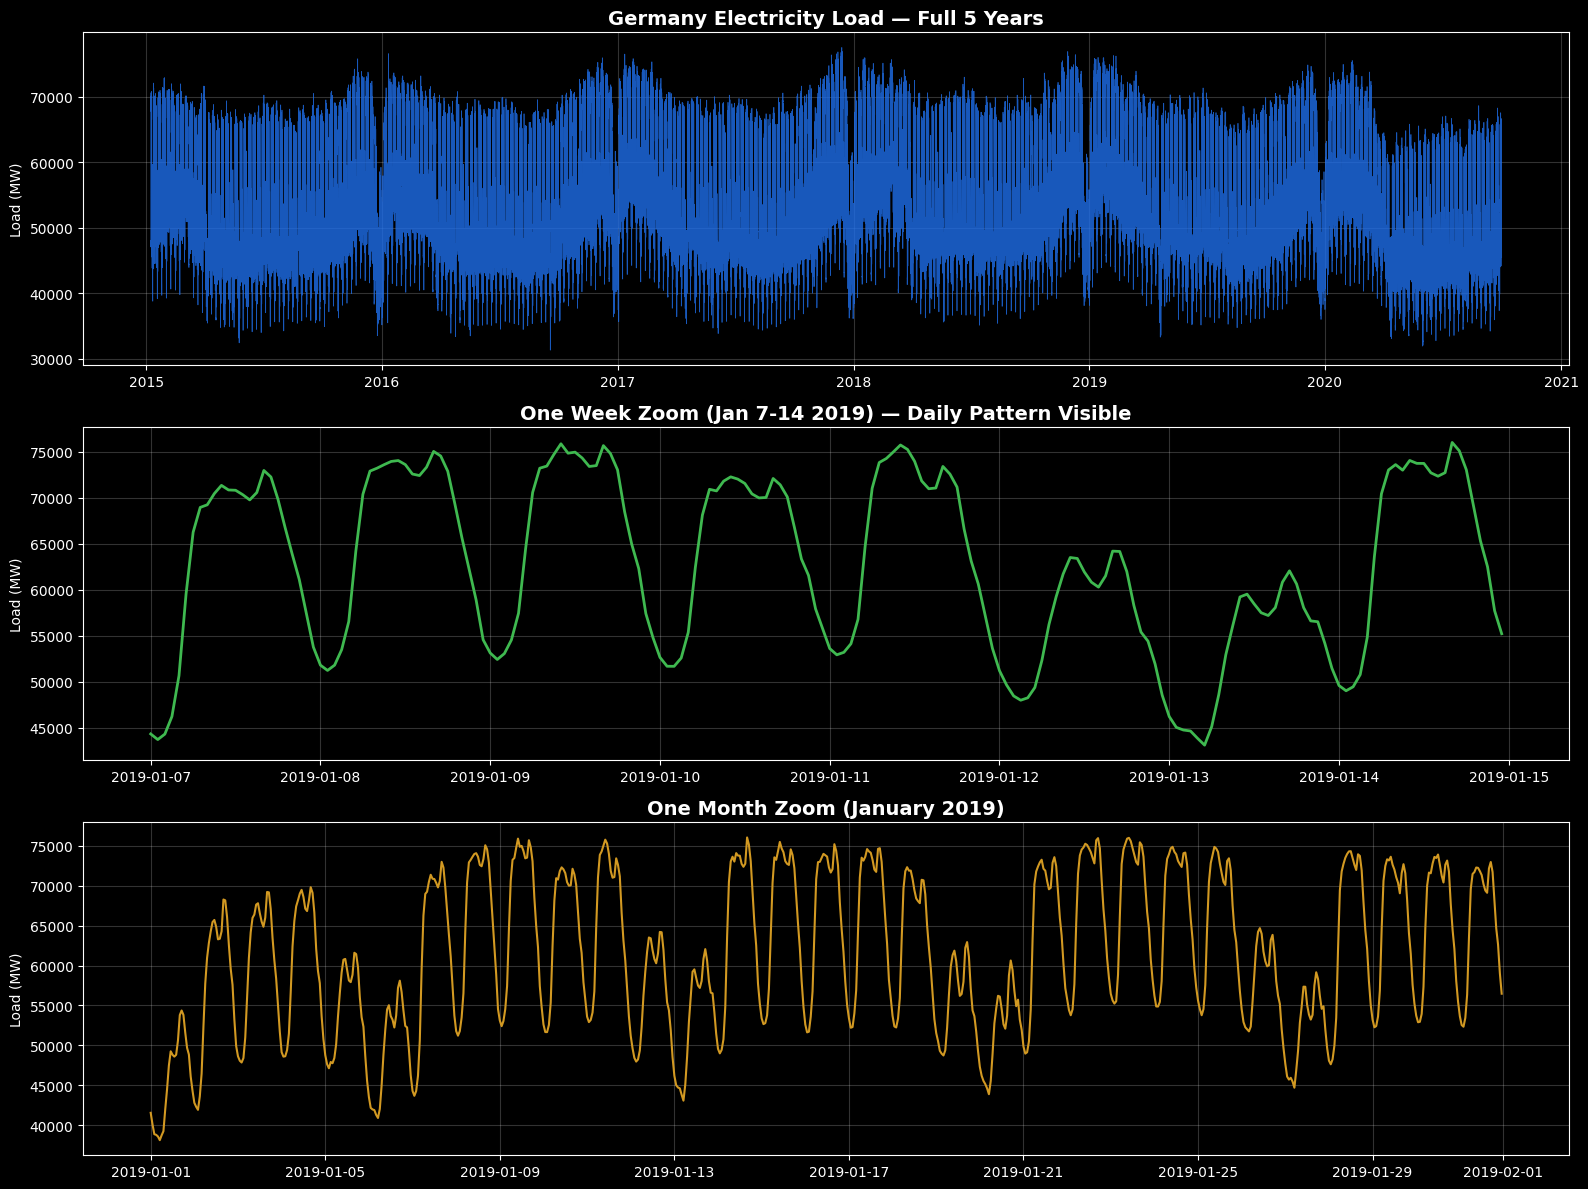

Plot 1 saved ✅


In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

# Create output folder for plots
import os
os.makedirs('../docs/plots', exist_ok=True)

# ── Plot 1: Load over time ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full time series
axes[0].plot(df_load_feat.index, 
             df_load_feat['load_actual'], 
             color='#1F6FEB', linewidth=0.5, alpha=0.8)
axes[0].set_title('Germany Electricity Load — Full 5 Years', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.2)

# One week zoom
one_week = df_load_feat['2019-01-07':'2019-01-14']
axes[1].plot(one_week.index, 
             one_week['load_actual'],
             color='#3FB950', linewidth=2)
axes[1].set_title('One Week Zoom (Jan 7-14 2019) — Daily Pattern Visible',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Load (MW)')
axes[1].grid(True, alpha=0.2)

# One month zoom
one_month = df_load_feat['2019-01-01':'2019-01-31']
axes[2].plot(one_month.index,
             one_month['load_actual'],
             color='#D29922', linewidth=1.5)
axes[2].set_title('One Month Zoom (January 2019)',
                   fontsize=14, fontweight='bold')
axes[2].set_ylabel('Load (MW)')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../docs/plots/01_load_timeseries.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved ✅")

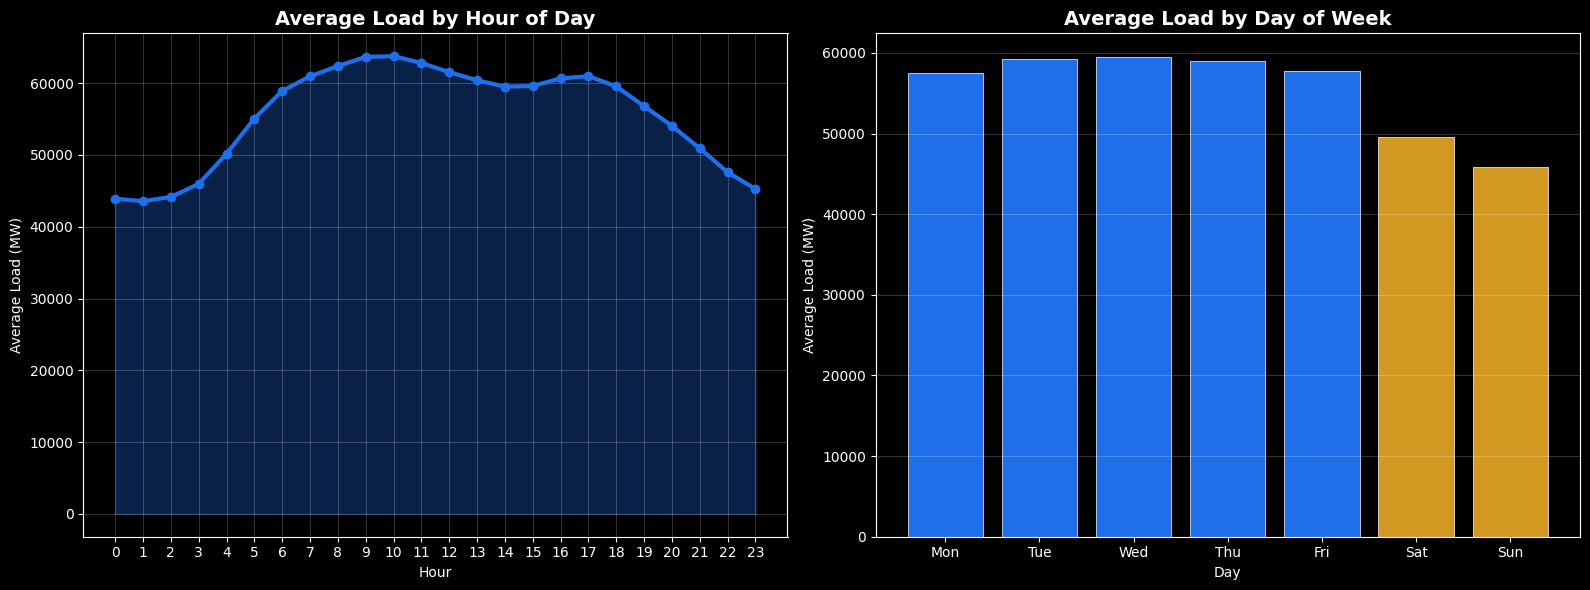

Plot 2 saved ✅


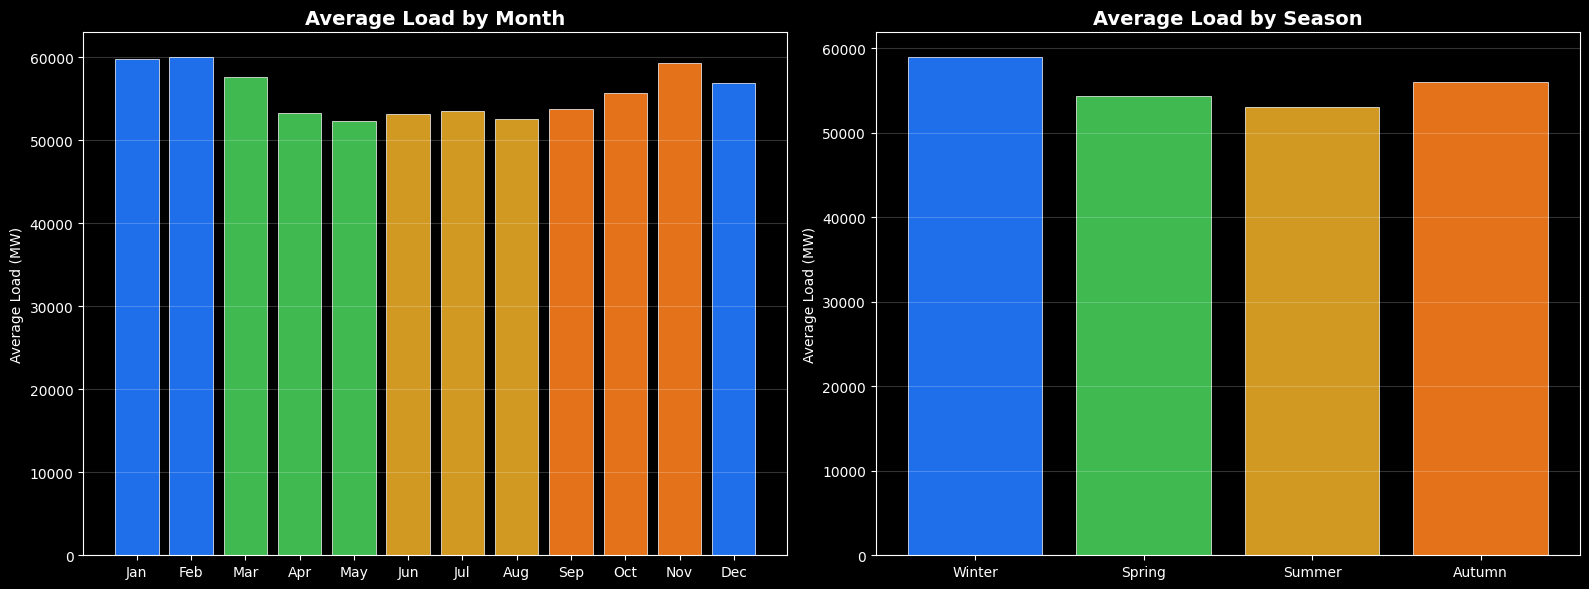

Plot 3 saved ✅


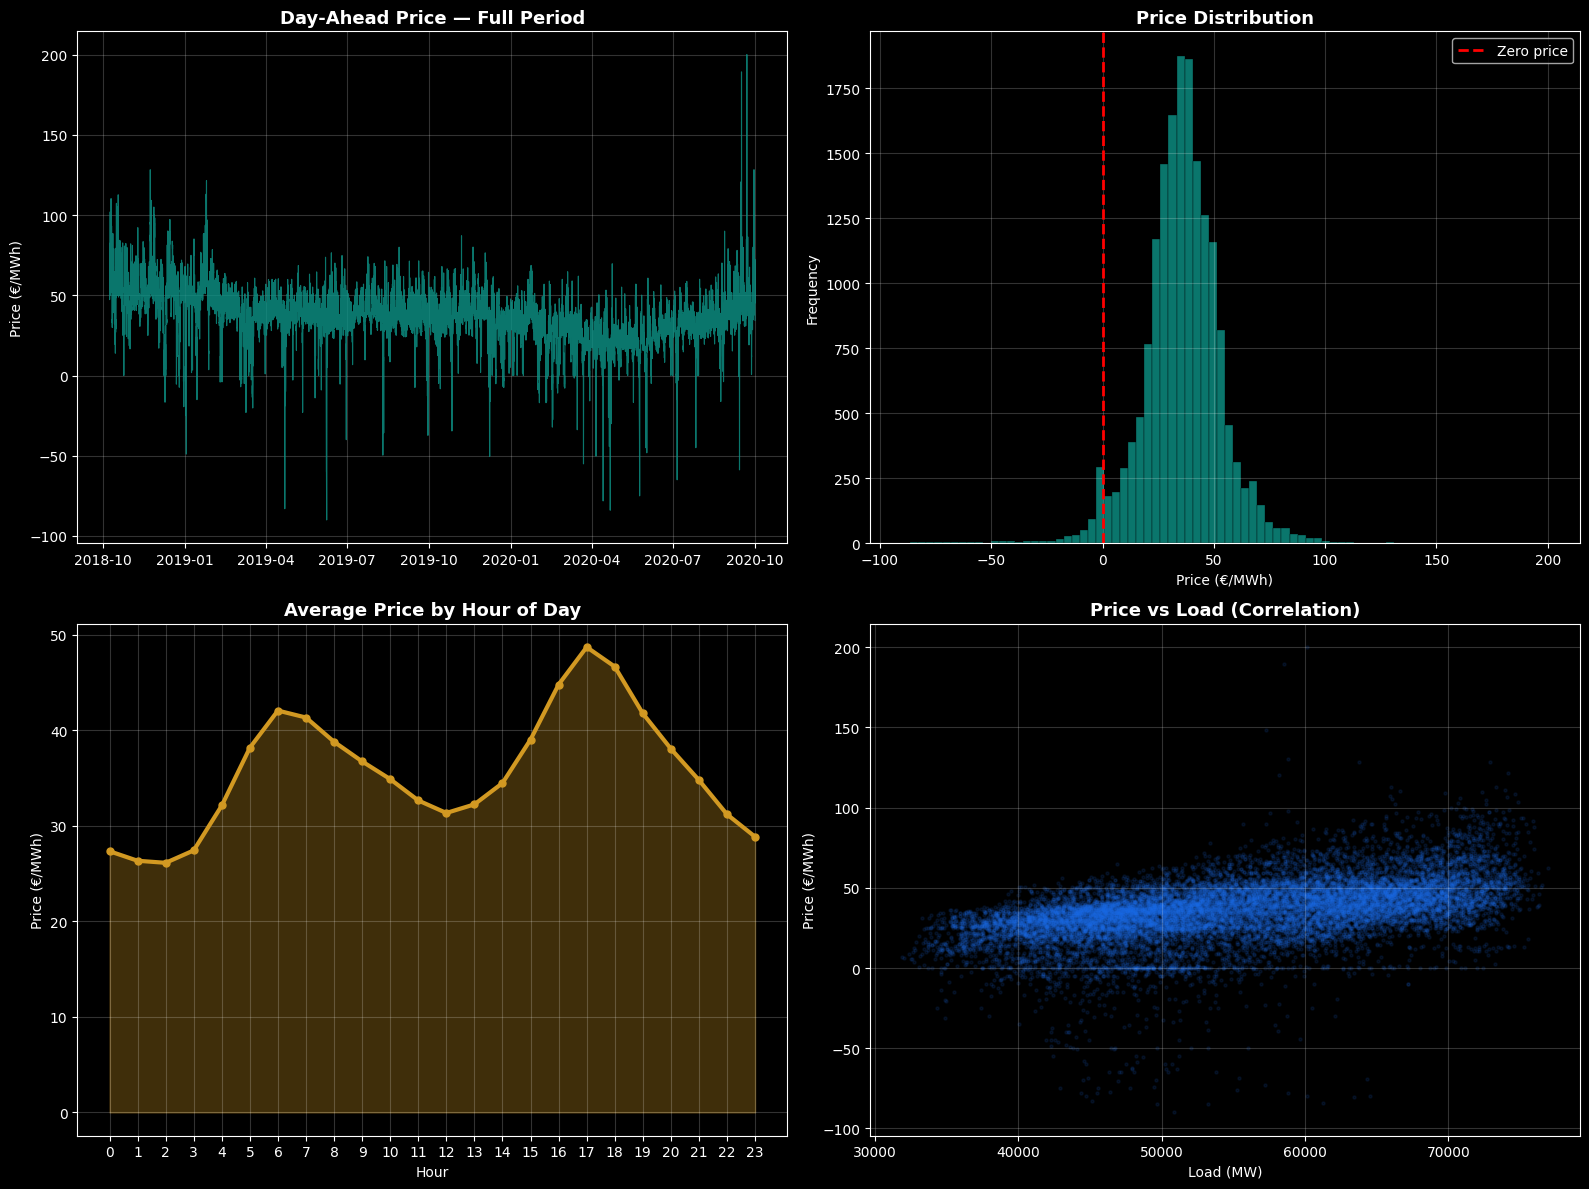

Plot 4 saved ✅


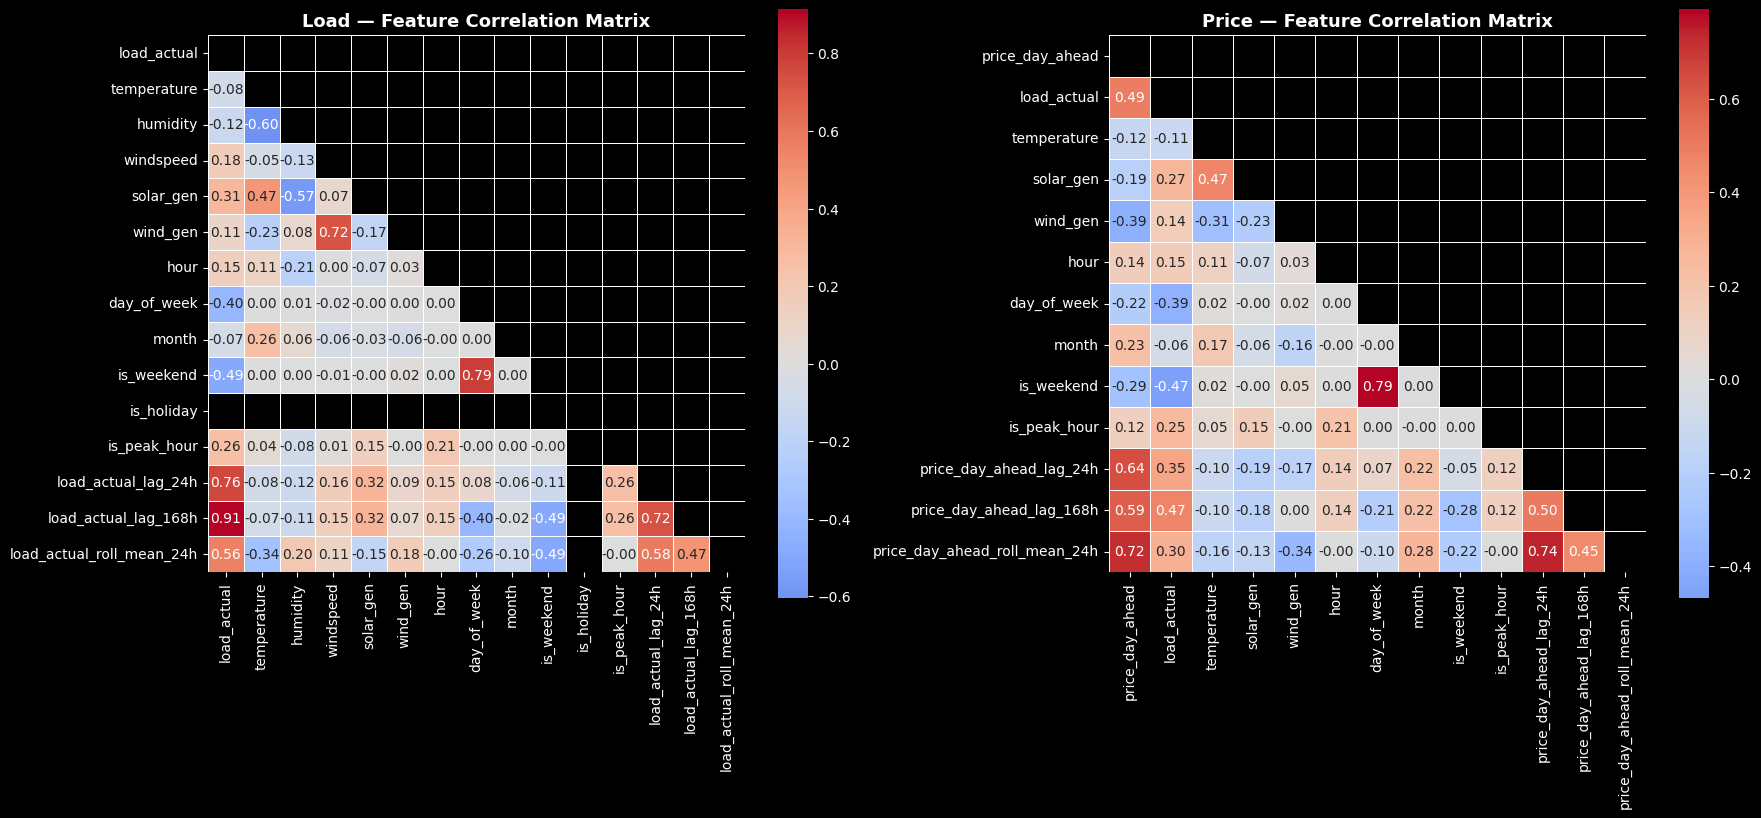

Plot 5 saved ✅


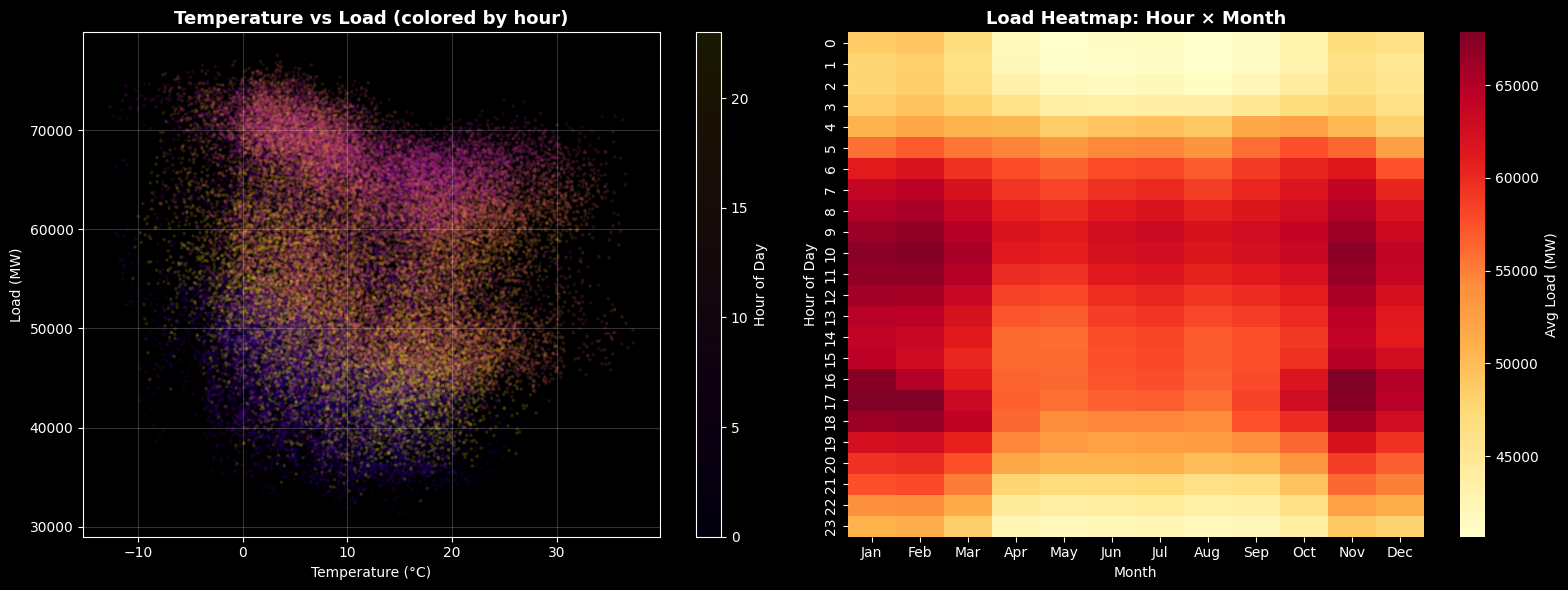

Plot 6 saved ✅

🎉 All EDA plots complete and saved to docs/plots/


In [36]:
# ── Plot 2: Average load by hour and day ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hourly average
hourly_avg = df_load_feat.groupby('hour')['load_actual'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, 
             color='#1F6FEB', linewidth=3, marker='o', markersize=6)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, 
                      alpha=0.3, color='#1F6FEB')
axes[0].set_title('Average Load by Hour of Day', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Load (MW)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.2)

# Day of week average
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df_load_feat.groupby('day_of_week')['load_actual'].mean()
colors = ['#1F6FEB']*5 + ['#D29922']*2
axes[1].bar(days, dow_avg.values, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Average Load by Day of Week', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Load (MW)')
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../docs/plots/02_load_patterns.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved ✅")

# ── Plot 3: Monthly and seasonal patterns ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df_load_feat.groupby('month')['load_actual'].mean()
season_colors = (['#1F6FEB']*2 + ['#3FB950']*3 + 
                 ['#D29922']*3 + ['#E3721B']*3 + ['#1F6FEB'])
axes[0].bar(months, monthly_avg.values, 
            color=season_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Average Load by Month', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Load (MW)')
axes[0].grid(True, alpha=0.2, axis='y')

season_avg = df_load_feat.groupby('season')['load_actual'].mean()
season_labels = ['Winter', 'Spring', 'Summer', 'Autumn']
season_col = ['#1F6FEB', '#3FB950', '#D29922', '#E3721B']
axes[1].bar(season_labels, season_avg.values, 
            color=season_col, edgecolor='white', linewidth=0.5)
axes[1].set_title('Average Load by Season', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Load (MW)')
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../docs/plots/03_seasonal_patterns.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved ✅")

# ── Plot 4: Price analysis ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price time series
axes[0,0].plot(df_price_feat.index, 
               df_price_feat['price_day_ahead'],
               color='#0D9488', linewidth=0.8, alpha=0.8)
axes[0,0].set_title('Day-Ahead Price — Full Period', 
                     fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Price (€/MWh)')
axes[0,0].grid(True, alpha=0.2)

# Price distribution
axes[0,1].hist(df_price_feat['price_day_ahead'], 
               bins=80, color='#0D9488', 
               edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0,1].axvline(x=0, color='red', linewidth=2, 
                   linestyle='--', label='Zero price')
axes[0,1].set_title('Price Distribution', 
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Price (€/MWh)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.2)

# Price by hour
price_hourly = df_price_feat.groupby('hour')['price_day_ahead'].mean()
axes[1,0].plot(price_hourly.index, price_hourly.values,
               color='#D29922', linewidth=3, 
               marker='o', markersize=5)
axes[1,0].fill_between(price_hourly.index, price_hourly.values,
                        alpha=0.3, color='#D29922')
axes[1,0].set_title('Average Price by Hour of Day', 
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Price (€/MWh)')
axes[1,0].set_xticks(range(0, 24))
axes[1,0].grid(True, alpha=0.2)

# Price vs Load scatter
axes[1,1].scatter(df_price_feat['load_actual'],
                  df_price_feat['price_day_ahead'],
                  alpha=0.1, color='#1F6FEB', s=5)
axes[1,1].set_title('Price vs Load (Correlation)', 
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Load (MW)')
axes[1,1].set_ylabel('Price (€/MWh)')
axes[1,1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../docs/plots/04_price_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved ✅")

# ── Plot 5: Correlation heatmap ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Load correlation
load_corr_cols = ['load_actual', 'temperature', 'humidity',
                  'windspeed', 'solar_gen', 'wind_gen',
                  'hour', 'day_of_week', 'month', 
                  'is_weekend', 'is_holiday', 'is_peak_hour',
                  'load_actual_lag_24h', 'load_actual_lag_168h',
                  'load_actual_roll_mean_24h']
corr_load = df_load_feat[load_corr_cols].corr()
mask = np.zeros_like(corr_load, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_load, mask=mask, ax=axes[0],
            cmap='coolwarm', center=0, 
            annot=True, fmt='.2f',
            square=True, linewidths=0.5)
axes[0].set_title('Load — Feature Correlation Matrix',
                   fontsize=13, fontweight='bold')

# Price correlation
price_corr_cols = ['price_day_ahead', 'load_actual', 
                   'temperature', 'solar_gen', 'wind_gen',
                   'hour', 'day_of_week', 'month',
                   'is_weekend', 'is_peak_hour',
                   'price_day_ahead_lag_24h',
                   'price_day_ahead_lag_168h',
                   'price_day_ahead_roll_mean_24h']
corr_price = df_price_feat[price_corr_cols].corr()
sns.heatmap(corr_price, mask=mask[:13,:13], ax=axes[1],
            cmap='coolwarm', center=0,
            annot=True, fmt='.2f',
            square=True, linewidths=0.5)
axes[1].set_title('Price — Feature Correlation Matrix',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/plots/05_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved ✅")

# ── Plot 6: Temperature vs Load ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: temp vs load
sc = axes[0].scatter(df_load_feat['temperature'],
                     df_load_feat['load_actual'],
                     c=df_load_feat['hour'],
                     cmap='plasma', alpha=0.1, s=3)
plt.colorbar(sc, ax=axes[0], label='Hour of Day')
axes[0].set_title('Temperature vs Load (colored by hour)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.2)

# Hourly load heatmap: hour vs month
pivot = df_load_feat.pivot_table(
    values='load_actual',
    index='hour',
    columns='month',
    aggfunc='mean'
)
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd',
            xticklabels=months, 
            cbar_kws={'label': 'Avg Load (MW)'})
axes[1].set_title('Load Heatmap: Hour × Month',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig('../docs/plots/06_temp_load_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 saved ✅")

print("\n🎉 All EDA plots complete and saved to docs/plots/")